## Sampling Techniques

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### Systematic Sampling

In [5]:
## select every 10th row fromm tips dataframe

shuffled_df = tips.sample(frac=1).reset_index(drop=True)
shuffled_df

,total_bill,tip,sex,smoker,day,time,size
0,26.86,3.14,Female,Yes,Sat,Dinner,2
1,11.69,2.31,Male,No,Thur,Lunch,2
2,15.98,2.03,Male,No,Thur,Lunch,2
3,11.17,1.50,Female,No,Thur,Lunch,2
4,19.81,4.19,Female,Yes,Thur,Lunch,2
...,...,...,...,...,...,...,...
239,8.51,1.25,Female,No,Thur,Lunch,2
240,22.23,5.00,Male,No,Sun,Dinner,2
241,18.64,1.36,Female,No,Thur,Lunch,3
242,18.71,4.00,Male,Yes,Thur,Lunch,3


In [6]:
systematic_sample = shuffled_df.iloc[::10]
systematic_sample

,total_bill,tip,sex,smoker,day,time,size
0,26.86,3.14,Female,Yes,Sat,Dinner,2
10,15.69,3.00,Male,Yes,Sat,Dinner,3
20,24.27,2.03,Male,Yes,Sat,Dinner,2
30,18.26,3.25,Female,No,Thur,Lunch,2
40,16.43,2.30,Female,No,Thur,Lunch,2
50,35.26,5.00,Female,No,Sun,Dinner,4
60,20.53,4.00,Male,Yes,Thur,Lunch,4
70,20.45,3.00,Male,No,Sat,Dinner,4
80,24.06,3.60,Male,No,Sat,Dinner,3
90,27.18,2.00,Female,Yes,Sat,Dinner,2


In [7]:
systematic_sample.shape

(25, 7)

## Stratified sampling
- Guarantees that representation of subgroups is maintained in the sample

In [8]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [12]:
# % of male , female in dataset
tips['sex'].value_counts()/len(tips)

,count
sex,
Male,0.643443
Female,0.356557


In [14]:
# % of male , female in dataset

systematic_sample = tips.iloc[::20]
systematic_sample['sex'].value_counts()/len(systematic_sample)

,count
sex,
Male,0.692308
Female,0.307692


In [25]:
from sklearn.model_selection import train_test_split

strata_property = 'sex'
stratified_sample,remaining_data = train_test_split(
    tips,     # population dataset
    train_size=0.15,    # % of population that we want as sample
    stratify=tips['sex'] # column/property on which we want stratification
    )
stratified_sample

,total_bill,tip,sex,smoker,day,time,size
25,17.81,2.34,Male,No,Sat,Dinner,4
31,18.35,2.50,Male,No,Sat,Dinner,4
110,14.00,3.00,Male,No,Sat,Dinner,2
70,12.02,1.97,Male,No,Sat,Dinner,2
52,34.81,5.20,Female,No,Sun,Dinner,4
90,28.97,3.00,Male,Yes,Fri,Dinner,2
228,13.28,2.72,Male,No,Sat,Dinner,2
174,16.82,4.00,Male,Yes,Sun,Dinner,2
86,13.03,2.00,Male,No,Thur,Lunch,2
146,18.64,1.36,Female,No,Thur,Lunch,3


In [23]:
stratified_sample.shape

(36, 7)

In [26]:
stratified_sample['sex'].value_counts()/len(stratified_sample)
## proportions of sex column are same in sample and population , which we needed

,count
sex,
Male,0.638889
Female,0.361111


## Simple Random Sampling

In [35]:
random_sample = tips.sample(n=35,random_state=10)
random_sample

,total_bill,tip,sex,smoker,day,time,size
162,16.21,2.00,Female,No,Sun,Dinner,3
60,20.29,3.21,Male,Yes,Sat,Dinner,2
61,13.81,2.00,Male,Yes,Sat,Dinner,2
63,18.29,3.76,Male,Yes,Sat,Dinner,4
69,15.01,2.09,Male,Yes,Sat,Dinner,2
83,32.68,5.00,Male,Yes,Thur,Lunch,2
55,19.49,3.51,Male,No,Sun,Dinner,2
211,25.89,5.16,Male,Yes,Sat,Dinner,4
46,22.23,5.00,Male,No,Sun,Dinner,2
35,24.06,3.60,Male,No,Sat,Dinner,3


In [36]:
random_sample,remaining_data = train_test_split(
    tips,     # population dataset
    train_size=0.15,    # % of population that we want as sample
    )
random_sample

,total_bill,tip,sex,smoker,day,time,size
128,11.38,2.00,Female,No,Thur,Lunch,2
85,34.83,5.17,Female,No,Thur,Lunch,4
118,12.43,1.80,Female,No,Thur,Lunch,2
47,32.40,6.00,Male,No,Sun,Dinner,4
151,13.13,2.00,Male,No,Sun,Dinner,2
72,26.86,3.14,Female,Yes,Sat,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2
28,21.70,4.30,Male,No,Sat,Dinner,2
202,13.00,2.00,Female,Yes,Thur,Lunch,2
165,24.52,3.48,Male,No,Sun,Dinner,3


## Inferential Statistics

## Sampling Distribution of sample means - continiuos data
- Sampling distribution is the distribution of sample means calculated from multiple random samples drawn from the population. This helps in estimating population parameters

In [37]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [40]:
population = tips['total_bill']

population_mean = np.mean(population)
population_std_dev = np.std(population)

In [55]:
## Step 1 : Draw m random samples from population
n = 30 # sample size
m = 500  # number of samples

In [56]:

sample_means = []

for i in range(m):
    sample = population.sample(n=n)
    sample_mean = np.mean(sample)
    sample_means.append(sample_mean)

In [57]:
len(sample_means)

## According to CLT, sample_means follow normal distribution

500

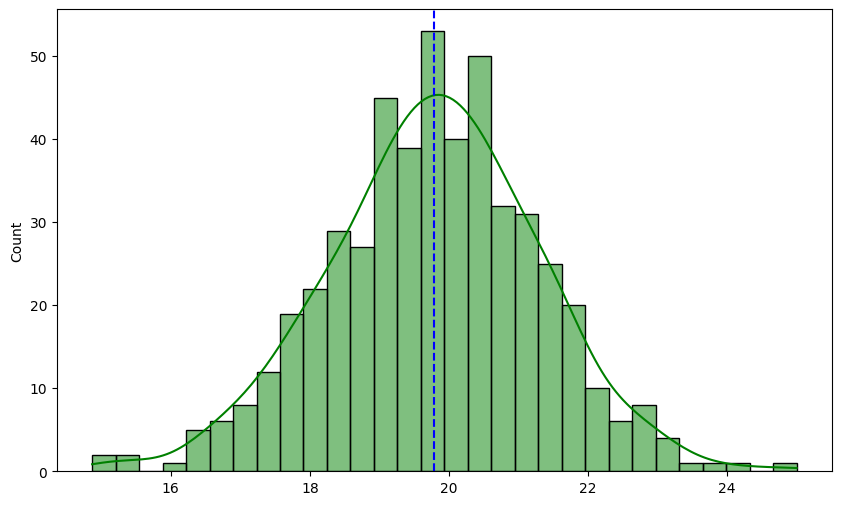

In [58]:
## Step 2: Visualise sampling distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(sample_means,kde=True,color='green',bins=30,label='Sampling Distribution of Sample Means')

plt.axvline(population_mean,color='blue',linestyle='--',label='Population Mean')
plt.show()

## Sampling Distribution of sample proportion - for categorical data

In [60]:
population = tips['sex']
population

,sex
0,Female
1,Male
2,Male
3,Male
4,Female
...,...
239,Male
240,Female
241,Male
242,Male


In [71]:
n = 30
m = 500

sample_proportions = []

## proportion of Male/Famale category in sample

for i in range(m):
    sample=population.sample(n=n)
    p = (sample.value_counts()/len(sample))['Male']
    sample_proportions.append(p)

In [72]:
len(sample_proportions)

500

<Axes: ylabel='Count'>

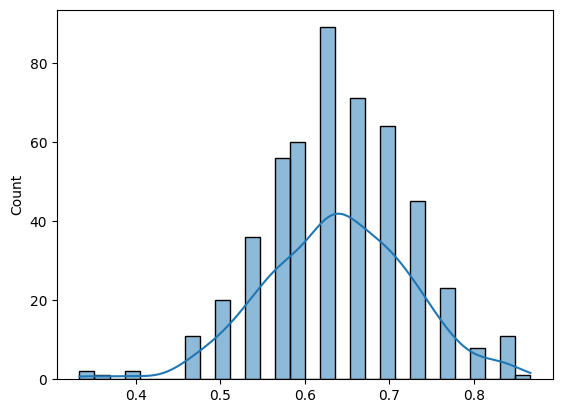

In [73]:
sns.histplot(sample_proportions,kde=True,bins=30)

In [67]:
## For continuous data - sample means follow normal distribution
## For categorical data - sample proportions follow normal distribution

## CLT is true for continuous as well as categorical data